In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('dark_background')

import re

import warnings 
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

In [2]:
data = pd.read_csv(r'D:\Data Science Projects\Car Price Prediction\Dataset\Dataset.csv')
data.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,...,Color,Airbags,Turbo,Engine_Volume_Num,Age,Age_Group,Mileage_Band,Inventory_Segment,Price_Per_Litre,Is_Premium_Brand
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,...,Silver,12,False,3.5,16,Old,High Mileage,Standard,3808.00,True
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000,...,Black,8,False,3.0,15,Old,High Mileage,Standard,5540.33,False
2,8467,0.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,...,Black,2,False,1.3,20,Old,High Mileage,Standard,6513.08,False
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,...,White,0,False,2.5,15,Old,High Mileage,Standard,1442.80,False
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,...,Silver,4,False,1.3,12,Old,Medium Mileage,Standard,9020.00,False


In [3]:
# Filter for numerical columns only
numerical_data = data.select_dtypes(include=['number'])

for col in numerical_data.columns:
    # Get the top 5 largest values
    top_5_values = numerical_data[col].nlargest(5)
    
    print(f"--- Top 5 Values for Column: {col} ---")
    
    # Loop through each of these top 5 values to find their frequency
    for value in top_5_values:
        # Count how many times this specific value appears in the entire column
        count = numerical_data[col].value_counts()[value]
        print(f"Value: {value} | Occurrences: {count}")
        
    print('='*35)

--- Top 5 Values for Column: Price ---
Value: 26307500 | Occurrences: 1
Value: 872946 | Occurrences: 1
Value: 627220 | Occurrences: 1
Value: 308906 | Occurrences: 1
Value: 297930 | Occurrences: 2
--- Top 5 Values for Column: Levy ---
Value: 11714.0 | Occurrences: 2
Value: 11714.0 | Occurrences: 2
Value: 11706.0 | Occurrences: 1
Value: 7536.0 | Occurrences: 1
Value: 7063.0 | Occurrences: 1
--- Top 5 Values for Column: Prod. year ---
Value: 2020 | Occurrences: 47
Value: 2020 | Occurrences: 47
Value: 2020 | Occurrences: 47
Value: 2020 | Occurrences: 47
Value: 2020 | Occurrences: 47
--- Top 5 Values for Column: Mileage ---
Value: 2147483647 | Occurrences: 7
Value: 2147483647 | Occurrences: 7
Value: 2147483647 | Occurrences: 7
Value: 2147483647 | Occurrences: 7
Value: 2147483647 | Occurrences: 7
--- Top 5 Values for Column: Cylinders ---
Value: 16.0 | Occurrences: 5
Value: 16.0 | Occurrences: 5
Value: 16.0 | Occurrences: 5
Value: 16.0 | Occurrences: 5
Value: 16.0 | Occurrences: 5
--- Top 5 

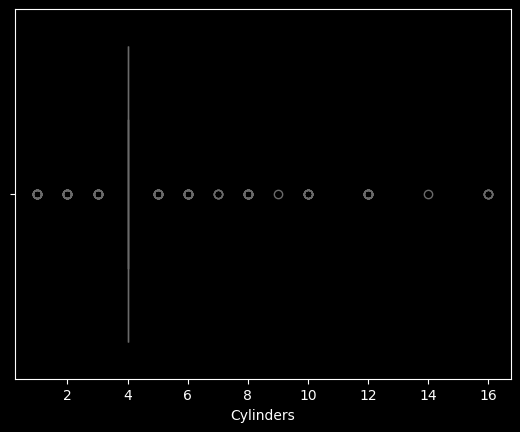

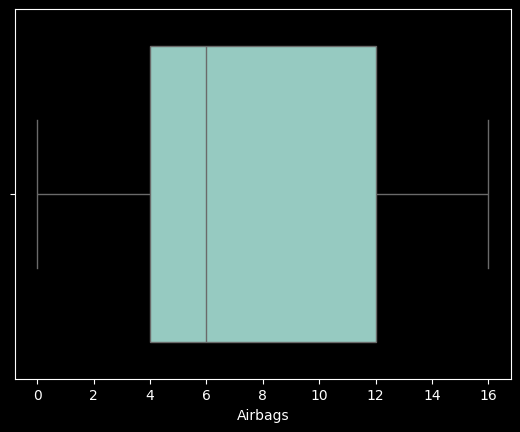

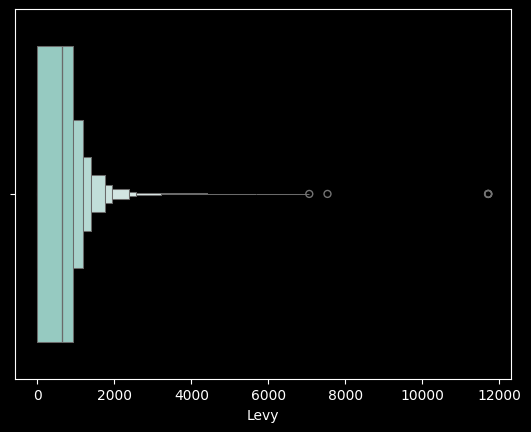

In [4]:
# Quickly visualize if these are extreme outliers
sns.boxplot(x=data['Cylinders'])
plt.show()

sns.boxplot(x=data['Airbags'])
plt.show()

sns.boxenplot(x=data['Levy'])
plt.show()

In [5]:
for col in data.columns:
    print(f"Column Name {col} is :\n {data[col].unique()}\n")
    print('='*35)

Column Name Price is :
 [13328 16621  8467 ... 56814 63886 22075]

Column Name Levy is :
 [ 1399.  1018.     0.   862.   446.   891.   761.   751.   394.  1053.
  1055.  1079.   810.  2386.  1850.   531.   586.  1249.  2455.   583.
  1537.  1288.   915.  1750.   707.  1077.  1486.  1091.   650.   382.
  1436.  1194.   503.  1017.  1104.   639.   629.   919.   781.   530.
   640.   765.   777.   779.   934.   769.   645.  1185.  1324.   830.
  1187.  1111.   760.   642.  1604.  1095.   966.   473.  1138.  1811.
   988.   917.  1156.   687. 11714.   836.  1347.  2866.  1646.   259.
   609.   697.   585.   475.   690.   308.  1823.  1361.  1273.   924.
   584.  2078.   831.  1172.   893.  1872.  1885.  1266.   447.  2148.
  1730.   730.   289.   502.   333.  1325.   247.   879.  1342.  1327.
  1598.  1514.  1058.   738.  1935.   481.  1522.  1282.   456.   880.
   900.   798.  1277.   442.  1051.   790.  1292.  1047.   528.  1211.
  1493.  1793.   574.   930.  1998.   271.   706.  1481.  

In [6]:
for col in data.columns:
    print(f"Column Name {col} is : \n {data[col].value_counts()}")
    print('='*35)

Column Name Price is : 
 Price
15681    274
470      264
392      237
14113    236
10976    233
        ... 
16280      1
11800      1
11666      1
18948      1
33         1
Name: count, Length: 2315, dtype: int64
Column Name Levy is : 
 Levy
0.0       5709
765.0      482
891.0      453
639.0      403
640.0      398
          ... 
2308.0       1
4860.0       1
1641.0       1
1045.0       1
1901.0       1
Name: count, Length: 559, dtype: int64
Column Name Manufacturer is : 
 Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
                 ... 
LAMBORGHINI         1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, Length: 65, dtype: int64
Column Name Model is : 
 Model
Prius               1069
Sonata              1067
Camry                929
Elantra              910
E 350                534
                    ... 
Vito Exstralong        1
Versa SE              

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18924 entries, 0 to 18923
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              18924 non-null  int64  
 1   Levy               18924 non-null  float64
 2   Manufacturer       18924 non-null  object 
 3   Model              18924 non-null  object 
 4   Prod. year         18924 non-null  int64  
 5   Category           18924 non-null  object 
 6   Leather interior   18924 non-null  object 
 7   Fuel type          18924 non-null  object 
 8   Engine volume      18924 non-null  object 
 9   Mileage            18924 non-null  int64  
 10  Cylinders          18924 non-null  float64
 11  Gear box type      18924 non-null  object 
 12  Drive wheels       18924 non-null  object 
 13  Doors              18924 non-null  object 
 14  Wheel              18924 non-null  object 
 15  Color              18924 non-null  object 
 16  Airbags            189

## Outliers Handling & Removing Unnecessary Columns

In [8]:
print(f"Row count before filtering: {data.shape[0]}")

# Exclude vintage vehicles (Age > 30) to ensure a homogeneous resale market.
data = data[data['Age'] <= 30]


# Remove cars < $500 (Likely 'junk' or errors)
# Remove cars > $300,000 (Supercars are not fit general pricing models)
data = data[(data['Price'] > 500) & (data['Price'] < 300000)]


# Remove cars with > 600,000 km
data = data[data['Mileage'] < 600000]


# Remove manufacturers > 5
mfr_counts = data['Manufacturer'].value_counts()
mfr_to_keep = mfr_counts[mfr_counts >= 5].index
data = data[data['Manufacturer'].isin(mfr_to_keep)]

data.reset_index(drop=True, inplace=True)


# Normalize car model names to ensure consistent categorical encoding,
# then filter out low-frequency models to minimize sparsity,
# reduce overfitting, and improve downstream model generalization
def clean_model_name(text):
    if pd.isna(text):
        return text
    text = str(text).upper().strip()
    text = re.sub(r'[^A-Z0-9 ]', ' ', text)
    text = " ".join(text.split())
    return text

data['Model'] = data['Model'].apply(clean_model_name)

data['Model'] = data['Model'].astype(str).str.strip().str.upper()

model_counts = data['Model'].value_counts()
models_to_keep = model_counts[model_counts > 10].index

data = data[data['Model'].isin(models_to_keep)].reset_index(drop=True)

data['Manufacturer'] = data['Manufacturer'].str.upper().str.strip()


# Remove unrealistic or extreme cylinder values to eliminate outliers
data = data[data['Cylinders'] <= 12]

data = data.drop(columns=['Engine volume'], axis=1)

data.rename(columns={
    'Engine_Volume_Num': 'Engine Volume'
}, inplace=True)


data['Engine_Efficiency'] = (data['Engine Volume'])/(data['Cylinders'])

data['is_levy_zero'] = (data['Levy'] == 0).astype(int)


# Step 1: Treat 0 as missing
data['Levy'] = data['Levy'].replace(0, np.nan)

# Step 2: Fill using median of same Age group
data['Levy'] = data.groupby('Age')['Levy'].transform(lambda x: x.fillna(x.median()))

data = data.drop(columns=[
    'Prod. year', 'Cylinders',
    'Price_Per_Litre', 'Wheel',
    'Doors','Age_Group',
    'Mileage_Band','Model'
])

print(f"Row count after filtering:  {data.shape[0]}")
print(f"Dropped {18924 - data.shape[0]} rows of garbage data")

Row count before filtering: 18924
Row count after filtering:  14550
Dropped 4374 rows of garbage data


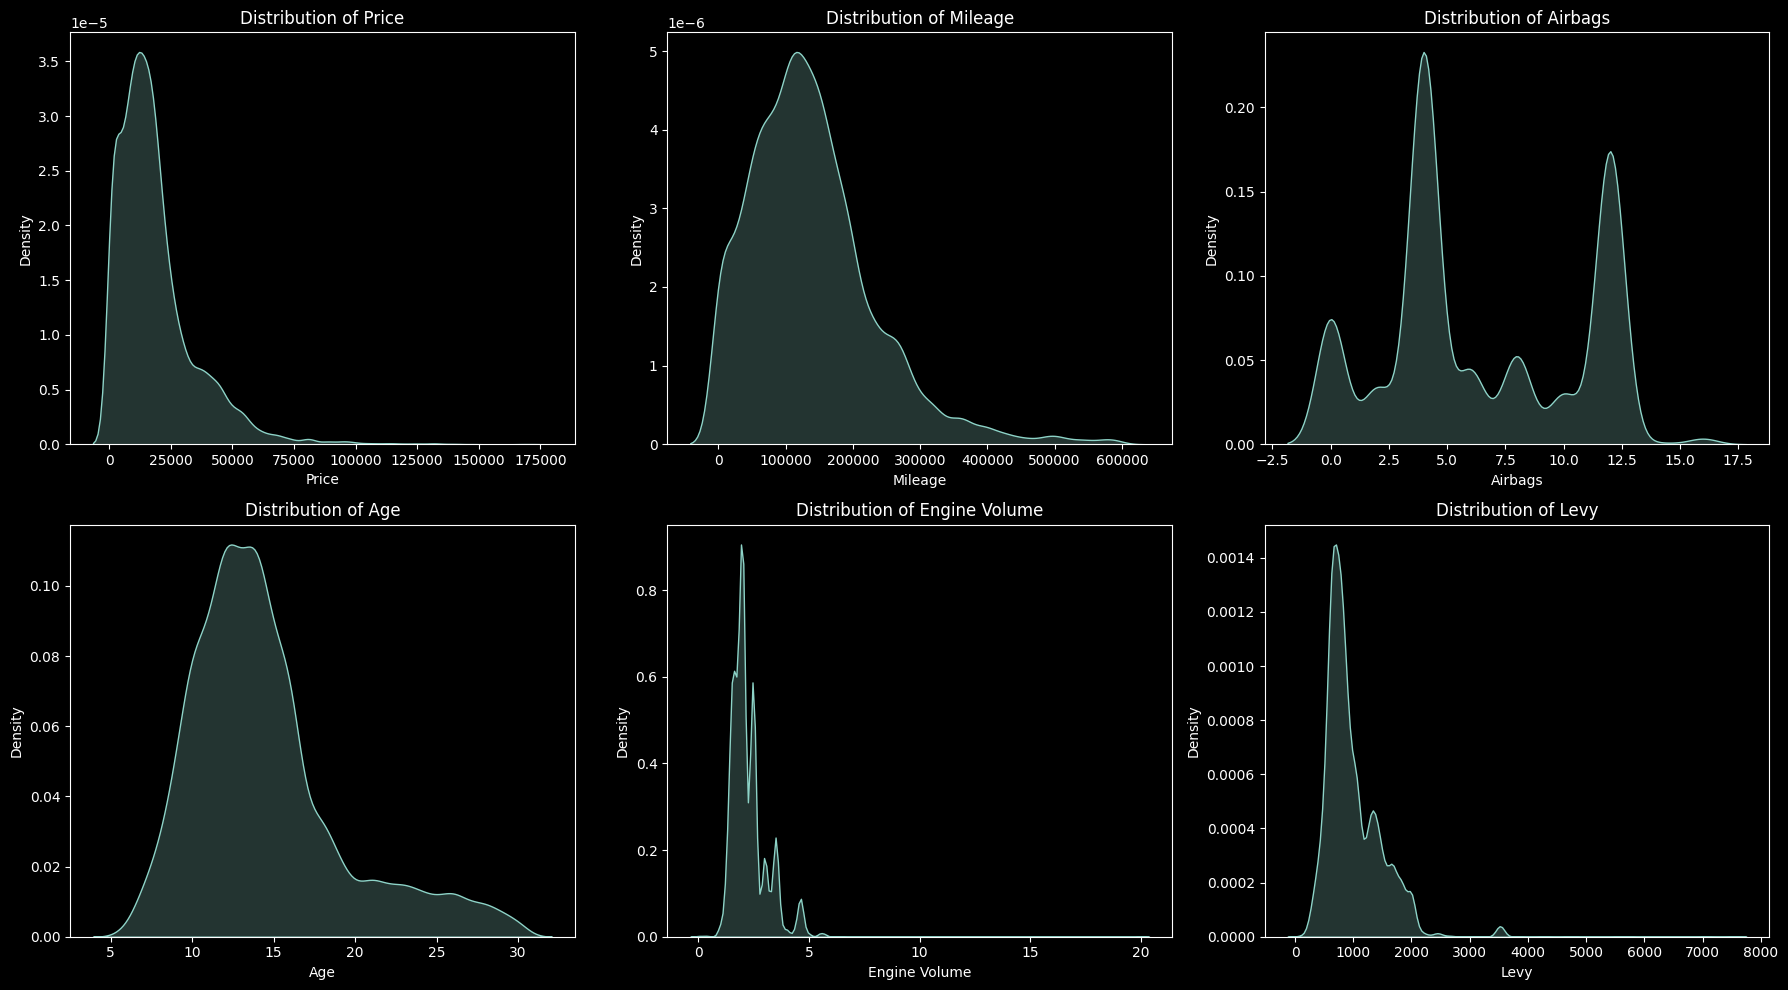

In [9]:
columns_to_plot = [
    'Price', 'Mileage','Airbags',
    'Age', 'Engine Volume',
    'Levy'
]

df_to_plot = data[columns_to_plot]

n_cols = 3  
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, col_name in enumerate(columns_to_plot):
    sns.kdeplot(data=df_to_plot, x=col_name, ax=axes[i], fill=True)
    axes[i].set_title(f'Distribution of {col_name}', fontsize=12)
    axes[i].set_xlabel(col_name, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)

for j in range(len(columns_to_plot), n_rows * n_cols):
    fig.delaxes(axes[j])
plt.tight_layout()

In [10]:
# 1. Filter for only numerical columns (int and float)
numerical_data = data.select_dtypes(include=['number'])

# 2. Loop through only those numerical columns
for col in numerical_data.columns:
    # Use nlargest for the best performance on top-N values
    top_5 = numerical_data[col].nlargest(5)
    
    print(f"Top 5 values for Numerical Column: {col}")
    print(top_5)
    print('='*35)

Top 5 values for Numerical Column: Price
2096     172486
5818     167781
6012     147397
2270     141124
11163    141124
Name: Price, dtype: int64
Top 5 values for Numerical Column: Levy
12941    7536.0
1644     7058.0
13432    5681.0
11102    5679.0
6142     5666.0
Name: Levy, dtype: float64
Top 5 values for Numerical Column: Mileage
3688     598779
1961     596900
11790    596900
1718     596107
729      595426
Name: Mileage, dtype: int64
Top 5 values for Numerical Column: Airbags
92      16
119     16
170     16
337     16
1005    16
Name: Airbags, dtype: int64
Top 5 values for Numerical Column: Engine Volume
1795     20.0
13438    20.0
6843      6.4
6973      6.4
864       6.2
Name: Engine Volume, dtype: float64
Top 5 values for Numerical Column: Age
144    30
365    30
513    30
767    30
885    30
Name: Age, dtype: int64
Top 5 values for Numerical Column: Engine_Efficiency
1795     5.0
13438    5.0
5805     3.2
6156     3.2
11079    3.0
Name: Engine_Efficiency, dtype: float64
Top

In [11]:
zero_airbags = (data['Airbags'] == 0).sum()
zero_mileage = (data['Mileage'] == 0).sum()
zero_enginevolume = (data['Engine Volume'] == 0).sum()


print(f"Value count of 0 in Airbags: {zero_airbags}")
print(f"Value count of 0 in Mileage: {zero_mileage}")
print(f"Value count of 0 in Engine Volume: {zero_enginevolume}")

Value count of 0 in Airbags: 1657
Value count of 0 in Mileage: 449
Value count of 0 in Engine Volume: 6


In [12]:
# Fix Mileage zeros using car Age
median_mileage = (data[data['Mileage'] > 0]['Mileage'] / data['Age']).median()
data.loc[data['Mileage'] == 0, 'Mileage'] = data['Age'] * median_mileage

# Fix Airbags zeros using Manufacturer/Category standards
data['Airbags'] = data.groupby(['Manufacturer', 'Category'])['Airbags'].transform(
    lambda x: x.replace(0, x[x > 0].median() if not x[x > 0].empty else 4)
)

# Replace 0 in Engine Volume using the median of the same Manufacturer and Model
data['Engine Volume'] = data.groupby(['Manufacturer'])['Engine Volume'].transform(
    lambda x: x.replace(0, x[x > 0].median() if not x[x > 0].empty else 2.0)
)
data['Mileage_Intensity'] = (data['Mileage'] / (data['Age'] + 1)).round(2)

data[['Is_Premium_Brand', 'Turbo']] = data[['Is_Premium_Brand', 'Turbo']].astype(str)

print(f"Remaining 0s in Mileage: {(data['Mileage'] == 0).sum()}")
print(f"Remaining 0s in Airbages: {(data['Airbags'] == 0).sum()}")
print(f"Remaining 0s in Engine Volume: {(data['Engine Volume'] == 0).sum()}")

Remaining 0s in Mileage: 0
Remaining 0s in Airbages: 0
Remaining 0s in Engine Volume: 0


In [13]:
X = data.drop(['Price'] , axis=1)
y = data['Price']

In [ ]:
# Grouping all numeric features together (no scaling or power transform needed)
from sklearn.preprocessing import TargetEncoder


numeric_features = ['Levy', 'Mileage', 'Age', 'Engine Volume', 'Mileage_Intensity', 'Airbags', 'is_levy_zero']

one_hot = ['Category', 'Fuel type', 'Gear box type', 'Color', 'Inventory_Segment']

binary_tranform = ['Leather interior', 'Turbo', 'Is_Premium_Brand']

high_cardinal = ['Manufacturer']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

one_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])


binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
    categories=[
        ['No', 'Yes'],  
        ['False', 'True'],  
        ['False', 'True']
    ]
))
])


high_card_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Target_Enc', TargetEncoder())
])

ensemble_transformer = ColumnTransformer([
    # No Scaling needed for Trees
    ('num', num_pipe, numeric_features),
    
    # Categorical encoding
    ('onehot', one_pipe, one_hot),
    
    # Binary encoding (Leather and Turbo)
    ('binary', binary_pipe, binary_tranform),
    
    # Frequency encoding for high cardinality
    ('high_card', high_card_pipe, high_cardinal)
])

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor
)
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.3,
    random_state=42)

ensemble_models = {
    'Random Forest': RandomForestRegressor(),
    'Extra Trees': ExtraTreesRegressor(),
    'Gradient Boost': GradientBoostingRegressor(),
    'XG Boost': XGBRegressor(),
    'Cat Boost': CatBoostRegressor(),
    'Light Boost': LGBMRegressor()
}



for name, model in ensemble_models.items():

    pipe = Pipeline([
        ('preprocess', ensemble_transformer),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    y_test_pred  = pipe.predict(X_test)
    y_train_pred = pipe.predict(X_train)

    print(name)

    print("Train Data Test")
    print("Train  MAE:", mean_absolute_error(y_train_pred, y_train))
    print("Train MSE", mean_squared_error(y_train_pred, y_train))
    print("Train R2 :", r2_score(y_train_pred, y_train))

    print('-'*40)
    
    print("Test Data Test")
    print("Test  MAE:", mean_absolute_error(y_test_pred, y_test))
    print("Test MSE", mean_squared_error(y_test_pred, y_test))
    print("Test  R2 :", r2_score(y_test_pred, y_test))
    print("="*40)

Random Forest
Train Data Test
Train  MAE: 2187.043497980081
Train MSE 16461851.950916559
Train R2 : 0.9255337171532342
----------------------------------------
Test Data Test
Test  MAE: 3366.114261309627
Test MSE 34728294.78270644
Test  R2 : 0.8554288271421161
Extra Trees
Train Data Test
Train  MAE: 1641.5515178203239
Train MSE 8928600.97150025
Train R2 : 0.9621260365677516
----------------------------------------
Test Data Test
Test  MAE: 3200.298926765941
Test MSE 32158486.963990655
Test  R2 : 0.8712836183067855
Gradient Boost
Train Data Test
Train  MAE: 4644.619095952289
Train MSE 44565445.60675234
Train R2 : 0.7708937417375845
----------------------------------------
Test Data Test
Test  MAE: 4845.766446622761
Test MSE 49558296.834809445
Test  R2 : 0.7656654647071339
XG Boost
Train Data Test
Train  MAE: 2819.557335556472
Train MSE 18438887.114864722
Train R2 : 0.921546995639801
----------------------------------------
Test Data Test
Test  MAE: 3690.094841333763
Test MSE 35232356.21

## Hyparameter Tunning

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

et_pipe = Pipeline([
    ('preprocess', ensemble_transformer),
    ('model', ExtraTreesRegressor(random_state=42))
])

et_params = {
    'model__n_estimators': randint(100, 400),
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': [1.0, 'sqrt', 'log2']
}

et_random = RandomizedSearchCV(
    et_pipe,
    param_distributions=et_params,
    n_iter=40,          # increase to 30–50 if time allows
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

et_random.fit(X_train, y_train)

print("Best ET Params:", et_random.best_params_)
print("Best ET Score:", et_random.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best ET Params: {'model__max_depth': 30, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 229}
Best ET Score: 0.8571483207002095


In [18]:
lgb_pipe = Pipeline([
    ('preprocess', ensemble_transformer),
    ('model', LGBMRegressor(random_state=42))
])

lgb_params = {
    'model__n_estimators': randint(100, 400),
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__num_leaves': randint(20, 80),
    'model__max_depth': [-1, 10, 20, 30]
}

lgb_random = RandomizedSearchCV(
    lgb_pipe,
    param_distributions=lgb_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

lgb_random.fit(X_train, y_train)

print("Best LGB Params:", lgb_random.best_params_)
print("Best LGB Score:", lgb_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19174
[LightGBM] [Info] Number of data points in the train set: 10185, number of used features: 1775
[LightGBM] [Info] Start training from score 18282.415906
Best LGB Params: {'model__learning_rate': 0.1, 'model__max_depth': 30, 'model__n_estimators': 363, 'model__num_leaves': 66}
Best LGB Score: 0.8542425014829895


In [19]:
cb_pipe = Pipeline([
    ('preprocess', ensemble_transformer),
    ('model', CatBoostRegressor(verbose=0, random_state=42))
])

cb_params = {
    'model__depth': randint(4, 10),
    'model__learning_rate': [0.01, 0.03, 0.05],
    'model__iterations': randint(500, 1200),
    'model__l2_leaf_reg': randint(1, 10)
}

cb_random = RandomizedSearchCV(
    cb_pipe,
    param_distributions=cb_params,
    n_iter=15,   # keep lower (CatBoost is slow)
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

cb_random.fit(X_train, y_train)

print("Best CB Params:", cb_random.best_params_)
print("Best CB Score:", cb_random.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CB Params: {'model__depth': 8, 'model__iterations': 1114, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.05}
Best CB Score: 0.8615490310730163


In [20]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

stack_model = StackingRegressor(
    estimators=[
        ('et', et_random.best_estimator_),
        ('lgb', lgb_random.best_estimator_),
        ('cb', cb_random.best_estimator_)
    ],
    final_estimator=Ridge(),
    cv=3,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

y_pred = stack_model.predict(X_test)

print("Stacking R2:", r2_score(y_test, y_pred))
print("Stacking MAE:", mean_absolute_error(y_test, y_pred))

Stacking R2: 0.8920140670378718
Stacking MAE: 3286.7231919048418


<Axes: xlabel='Price', ylabel='Count'>

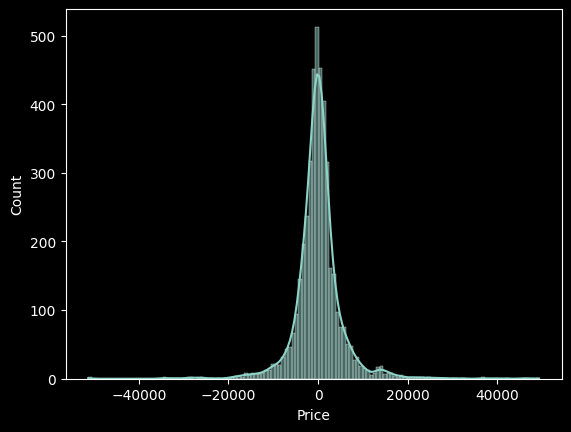

In [22]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)

# Summary

This notebook focuses on building a robust car price prediction model using supervised machine learning. The dataset was first loaded and explored through column-wise inspection, value counts, and outlier analysis. Several unrealistic records were removed, including extreme car ages, price values, mileage values, rare manufacturers, rare models, and invalid cylinder-related records. Missing or zero values in important numerical fields were then handled carefully: mileage, airbags, engine volume, and levy were repaired using grouped median-based logic and domain-based feature engineering. Additional useful features such as Engine_Efficiency, Mileage_Intensity, and is_levy_zero were created to improve predictive power.

After preprocessing, the data was divided into numerical, one-hot encoded, binary, and high-cardinality categorical features. A custom preprocessing pipeline was built using ColumnTransformer and Pipeline to prepare the data consistently for multiple ensemble regressors. Several models were trained and compared, including Random Forest, Extra Trees, Gradient Boosting, XGBoost, CatBoost, and LightGBM. Among the baseline models, Extra Trees performed best on the test set, followed closely by CatBoost and XGBoost, while Gradient Boosting showed weaker performance.

To improve model performance further, RandomizedSearchCV was applied to the top three models: Extra Trees, LightGBM, and CatBoost. The best cross-validated results were obtained by CatBoost, with Extra Trees and LightGBM close behind. Finally, a stacking ensemble was created using the tuned Extra Trees, LightGBM, and CatBoost models with Ridge as the final estimator. This stacked model produced the best overall performance, achieving a test R² of about 0.892 and MAE of about 3286.7. Residual analysis showed that prediction errors were mostly centered around zero, indicating a reasonably unbiased model, though some outliers still caused larger errors. Overall, this notebook demonstrates a complete end-to-end machine learning workflow from data cleaning and feature engineering to model selection, hyperparameter tuning, and ensemble learning.